# Testing MG-cs2

In this notebook, I test a novel scenario in which the dark energy sound speed sources the braiding function $\alpha_B$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import camb

In [16]:
def get_camb_solution(alpha_K, cs2, omega_m, w0, wa, use_cs2):
    ombh2 = 0.0122
    h = 0.7
    omch2 = (omega_m - ombh2/h**2)*h**2
    cosmo = camb.set_params(
        H0=100*h, ombh2=ombh2, omch2=omch2, As=2.1e-9, ns=0.96, tau=0.06,
        num_nu_massless=3.044, WantTransfer=True, w=w0, wa=wa,
        dark_energy_model="fluid" if (1+w0)*(1+w0+wa) > 0 else "ppf",
        cs2_0=cs2, use_cs2=use_cs2, alpha_K=alpha_K
    )
    cosmo.set_matter_power(redshifts=(0,), kmax=3)
    results = camb.get_background(cosmo)
    cl_tt = results.get_cmb_power_spectra(cosmo, CMB_unit="muK")["total"][:, 0]
    kh, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints=200)
    log_a = results.Params.log_a
    alpha_B = results.Params.alpha_B
    mu = results.Params.mu
    return log_a, alpha_B, mu, kh, z, pk, cl_tt

Text(0, 0.5, '$\\mu$')

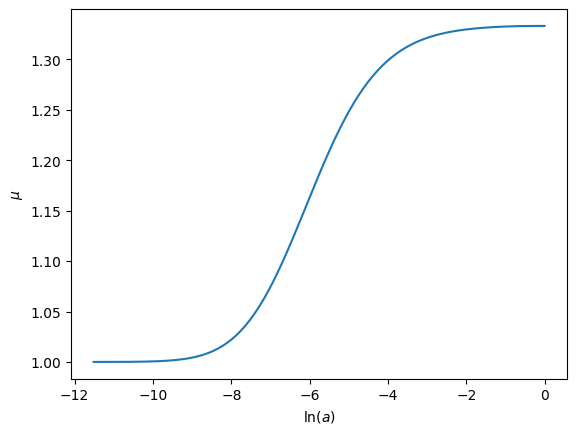

In [26]:
log_a, alpha_B, mu, kh, z, pk, cl_tt = get_camb_solution(1e-4, 1, 0.3, -0.9, -0.6, use_cs2=True)
_, _, _, kh, z, pk_gr, cl_tt_gr      = get_camb_solution(1e-4, 1, 0.3, -0.9, -0.6, use_cs2=False)
plt.plot(log_a, mu)
plt.xlabel("$\\ln(a)$")
plt.ylabel("$\\mu$")

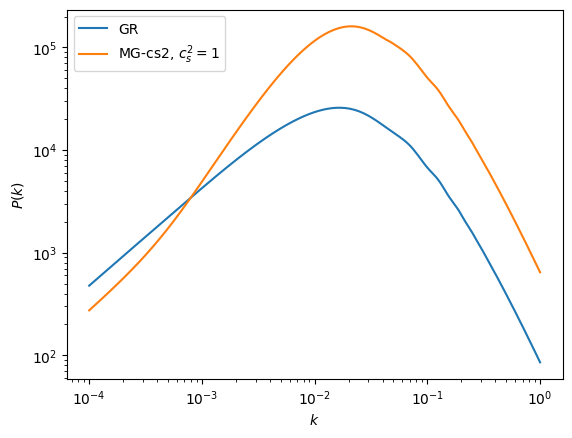

In [28]:
plt.loglog(kh, pk_gr[0], label="GR")
plt.loglog(kh, pk[0], label="MG-cs2, $c_s^2 = 1$")
plt.xlabel("$k$")
plt.ylabel("$P(k)$")
plt.legend()